# Example of usage of open_save code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [144]:
R = 1.
r = 0.75

NGSOLVE = True

lc = 0.2

if NGSOLVE:
    from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
    #mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
    mesh = CleanCircle(R=R, verbosity=0, lc=lc)
else:
    raise NotImplementedError
    from cases.open_space.gmsh_geometries import CleanWaveguide, WaveguideRegions
    mesh = CleanWaveguide(R=R, H=H, verbose=True, lc=lc)


In [145]:
mesh.n_triangles

166

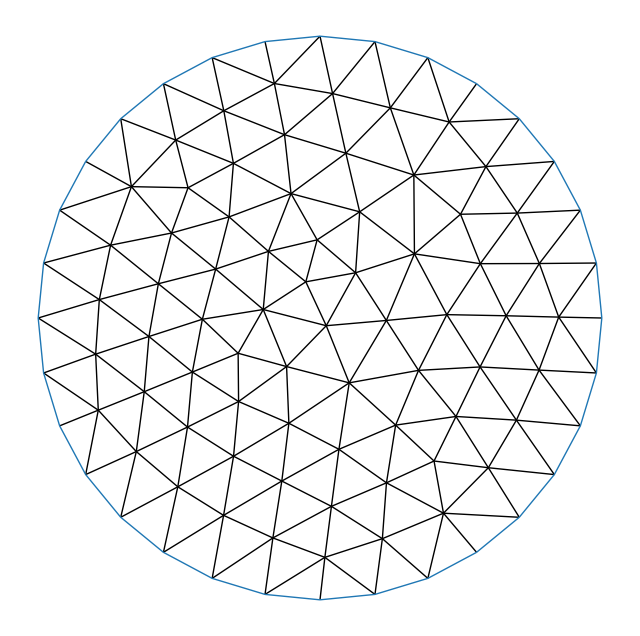

In [146]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [147]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

In [148]:
mesh.curve_region(Regions.SIGMA, radius=R)
#mesh.curve_region(Regions.d_Omega, radius=r)


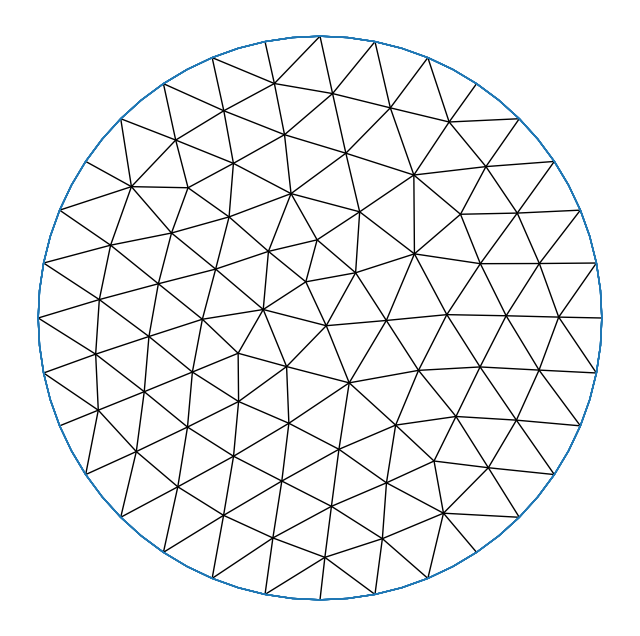

In [149]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [150]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [151]:
import numpy as np
data = {"d_inc": np.array([-1., 0.])}
# boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}
boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [152]:
from trefftz.dg.serial_kernels import UltraWeakKernel, CircularDirichletKernel


as well as specific ones (for a circular NtD map):

In [153]:
from cases.open_space.kernels import NtDLocal_circle, NtDNonLocal_circle

Now the numerics (the configuration of kernels) is almost a dictionary:

In [217]:
from trefftz.dg.assemblers import SerialNumerics
NtD_modes = 5
# numerics = SerialNumerics(interior_kernel=UltraWeakKernel(a=0.5, b=0.5),
#                           local_boundary_kernels={NtDBC: NtDLocal_circle(R=R, d_2=0.5, n=1), DirichletBC: CircularDirichletKernel(a=0.5, data=data)},
#                           nonlocal_boundary_kernels= {NtDBC: NtDNonLocal_circle(R=R, d_2=0.5, n=1, NtD_modes=NtD_modes)})

numerics = SerialNumerics(interior_kernel=UltraWeakKernel(a=0.5, b=0.5),
                          local_boundary_kernels={DirichletBC: CircularDirichletKernel(a=0.5, data=data)},
                          nonlocal_boundary_kernels={})

We should also choose a local basis

In [218]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 11
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

and an assembler:

In [219]:
basis.N_DOF

1826

In [220]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [221]:
assembler._regions_RHS_term

[<Regions.SIGMA: 'Sigma'>]

so we can set the problem:

In [222]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler)

In [223]:
A = P.assemble_LHS()

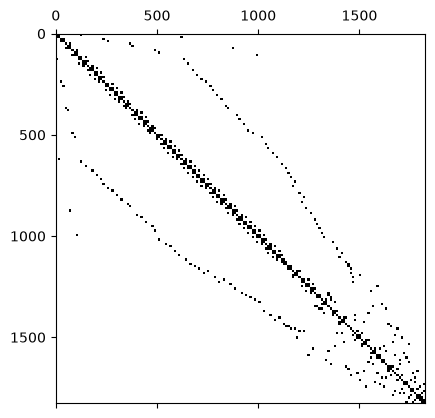

In [224]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [225]:
b = P.assemble_RHS()

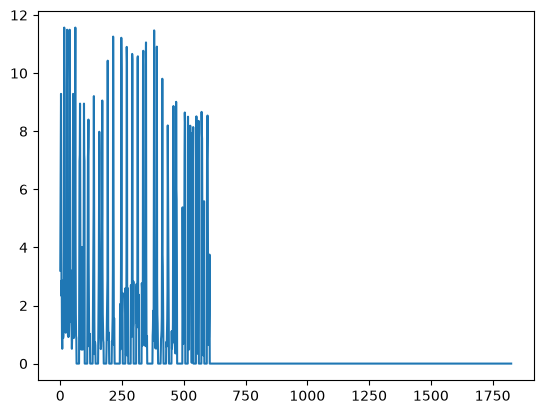

In [226]:
import numpy as np 
plt.plot(np.abs(b))

In [227]:
P.solve()

In [228]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 1.37211324e+02+5.41957605e+02j, -1.04888710e+03+6.13426986e+02j,
        -1.05798127e+03+6.68398965e+02j, ...,
         1.30310852e+02+1.44614655e+02j, -9.17753609e+01+2.03805680e+01j,
         1.01520089e+02-1.22690793e+02j],
       [-3.80158921e+03+2.73440649e+03j, -2.58336643e+03-9.91076661e+02j,
         1.76539737e+03-9.97619338e+02j, ...,
        -8.09407400e+02+1.77856196e+03j, -3.83857902e+03+5.60299549e+03j,
        -8.73145573e+02+9.13626065e+03j],
       [-2.07662534e+02+2.55062784e+02j,  1.49451735e+03+8.34233261e-01j,
         6.79132890e+02-3.38952626e+02j, ...,
         9.97954917e+02+3.82290032e+03j,  2.44951163e+03-7.82146033e+02j,
        -1.88408575e+02-1.14970684e+03j],
       ...,
       [ 5.18243027e+00-6.09693525e+00j, -3.92044838e+00-9.29405495e+00j,
         5.30800491e+00+1.93103200e+01j, ...,
         7.60485743e+00+3.11391740e+01j,  2.11034768e+00+3.69018167e+00j,
        -6.59146222e-01+9.59348854e+00j],
       [ 1.51038421e+01-4.26276995e+01j, -4.

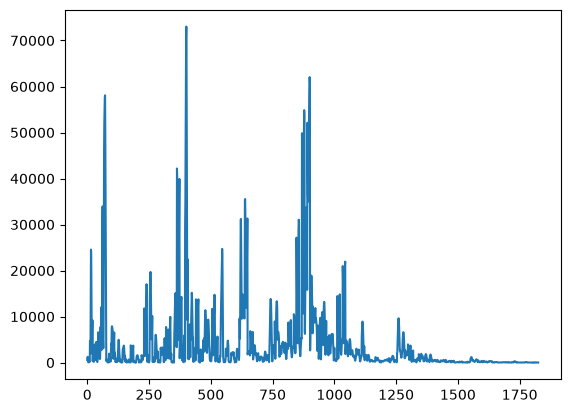

In [229]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [230]:
import numpy as np
N = 200
rs = np.linspace(r, R, N)
rs = np.linspace(0, R, N)

theta = np.linspace(0, 2*np.pi, N)
Rs, Theta = np.meshgrid(rs, theta)
X = Rs*np.cos(Theta)
Y = Rs*np.sin(Theta)
x = X.ravel()
y = Y.ravel() 
z = P.u_h(x, y)

(np.float64(-1.09986915899354),
 np.float64(1.100062304173604),
 np.float64(-1.099965731583572),
 np.float64(1.099965731583572))

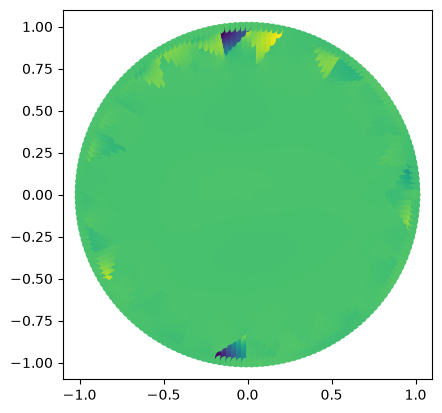

In [231]:
import matplotlib.pyplot as plt
plt.scatter(x,y,c=np.real(z),cmap="viridis")
plt.axis("square")